# Formula 1 Race Intelligence

## Exploratory Data Analysis (EDA) - Metadata

### Objetivo

Este notebook tiene como objetivo realizar un análisis exploratorio de los datasets de metadatos obtenidos a través de la API OpenF1 para las temporadas 2024, 2025 y 2026.

Durante este proceso se analizará la estructura de los datos, su calidad, la presencia de valores nulos o duplicados y las principales características de cada conjunto de datos.

Los datasets estudiados son:

- sessions_raw.csv
- drivers_raw.csv
- stints_raw.csv
- weather_raw.csv
- race_control_raw.csv

Los resultados obtenidos permitirán comprender mejor la información disponible antes de realizar las fases de limpieza, transformación y desarrollo del dashboard final.

## Importación de librerías

Se importan las librerías necesarias para la manipulación, análisis y visualización de los datos.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## Carga de los datasets

A continuación se cargan los distintos conjuntos de datos extraídos desde OpenF1 que serán analizados durante este notebook.

In [3]:
sessions = pd.read_csv("../data/raw/sessions_raw.csv")
drivers = pd.read_csv("../data/raw/drivers_raw.csv")
stints = pd.read_csv("../data/raw/stints_raw.csv")
weather = pd.read_csv("../data/raw/weather_raw.csv")
race_control = pd.read_csv("../data/raw/race_control_raw.csv")

print("Datasets cargados correctamente")

Datasets cargados correctamente


## Inspección inicial de los datasets

Antes de comenzar el análisis es necesario comprender la estructura de cada dataset.
Se revisarán:
- Número de filas y columnas.
- Tipos de datos.
- Valores nulos.
- Registros duplicados.
- Estadísticas descriptivas.

In [4]:
datasets = {
    "sessions": sessions,
    "drivers": drivers,
    "stints": stints,
    "weather": weather,
    "race_control": race_control,
}

for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"DATASET: {name}")
    print(f"{'='*60}")

    print("Shape:")
    print(df.shape)

    print("\nDuplicados:")
    print(df.duplicated().sum())

    print("\nNulos:")
    print(df.isnull().sum().sum())


DATASET: sessions
Shape:
(372, 16)

Duplicados:
0

Nulos:
0

DATASET: drivers
Shape:
(3717, 19)

Duplicados:
0

Nulos:
2615

DATASET: stints
Shape:
(9400, 15)

Duplicados:
0

Nulos:
59

DATASET: weather
Shape:
(15194, 17)

Duplicados:
0

Nulos:
0

DATASET: race_control
Shape:
(10078, 18)

Duplicados:
0

Nulos:
38408


# Dataset Sessions

Este dataset contiene información sobre todas las sesiones disputadas durante las temporadas analizadas.

Incluye información relativa al circuito, país, fecha, tipo de sesión y otros metadatos relevantes.

El objetivo de este análisis es verificar que todas las sesiones han sido correctamente recuperadas y comprobar la distribución de los distintos tipos de eventos disponibles.

In [8]:
sessions.head()


,session_key,session_type,session_name,date_start,date_end,meeting_key,circuit_key,circuit_short_name,country_key,country_code,country_name,location,gmt_offset,year,is_cancelled,season
0,9462,Practice,Day 1,2024-02-21T07:00:00+00:00,2024-02-21T16:00:00+00:00,1228,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2024,False,2024
1,9463,Practice,Day 2,2024-02-22T07:00:00+00:00,2024-02-22T16:00:00+00:00,1228,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2024,False,2024
2,9464,Practice,Day 3,2024-02-23T07:00:00+00:00,2024-02-23T16:00:00+00:00,1228,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2024,False,2024
3,9465,Practice,Practice 1,2024-02-29T11:30:00+00:00,2024-02-29T12:30:00+00:00,1229,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2024,False,2024
4,9466,Practice,Practice 2,2024-02-29T15:00:00+00:00,2024-02-29T16:00:00+00:00,1229,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2024,False,2024


In [9]:
sessions["session_name"].value_counts()

session_name
Qualifying           72
Practice 1           72
Race                 72
Practice 2           54
Practice 3           54
Sprint Qualifying    18
Sprint               18
Day 1                 4
Day 2                 4
Day 3                 4
Name: count, dtype: int64

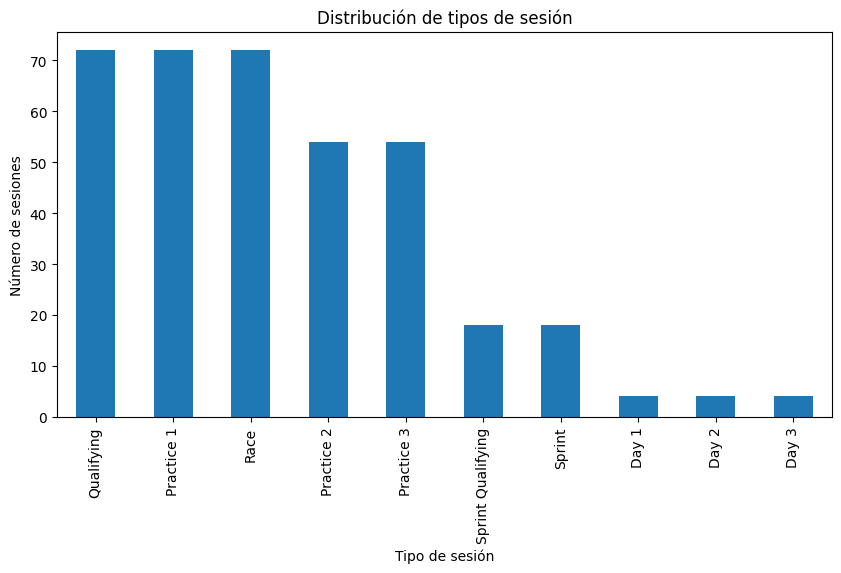

In [10]:
sessions["session_name"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Distribución de tipos de sesión")
plt.xlabel("Tipo de sesión")
plt.ylabel("Número de sesiones")
plt.show()

### Conclusiones

Se observa la presencia de sesiones de carrera, clasificación, sprint y prácticas.

La distribución obtenida es coherente con la estructura oficial de los fines de semana de Fórmula 1 para las temporadas analizadas.

No se detectan inconsistencias aparentes en la información recuperada.

# Dataset Drivers

Este dataset contiene información descriptiva de los pilotos participantes en las distintas sesiones.

Se analizarán aspectos relacionados con los equipos participantes y la distribución de pilotos por temporada.

In [11]:
drivers.head()

,meeting_key,session_key,driver_number,broadcast_name,full_name,name_acronym,team_name,team_colour,first_name,last_name,headshot_url,country_code,season,country_name,location_name,session_name,session_type,date_start_session,date_end_session
0,1229,9468,1,M VERSTAPPEN,Max VERSTAPPEN,VER,Red Bull Racing,3671c6,Max,Verstappen,https://media.formula1.com/d_driver_fallback_i...,NED,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
1,1229,9468,2,L SARGEANT,Logan SARGEANT,SAR,Williams,64c4ff,Logan,Sargeant,https://media.formula1.com/d_driver_fallback_i...,USA,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
2,1229,9468,3,D RICCIARDO,Daniel RICCIARDO,RIC,RB,6692ff,Daniel,Ricciardo,https://media.formula1.com/d_driver_fallback_i...,AUS,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
3,1229,9468,4,L NORRIS,Lando NORRIS,NOR,McLaren,ff8000,Lando,Norris,https://media.formula1.com/d_driver_fallback_i...,GBR,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
4,1229,9468,10,P GASLY,Pierre GASLY,GAS,Alpine,ff87bc,Pierre,Gasly,https://media.formula1.com/d_driver_fallback_i...,FRA,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00


In [14]:
drivers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3717 entries, 0 to 3716
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   meeting_key         3717 non-null   int64 
 1   session_key         3717 non-null   int64 
 2   driver_number       3717 non-null   int64 
 3   broadcast_name      3717 non-null   object
 4   full_name           3717 non-null   object
 5   name_acronym        3717 non-null   object
 6   team_name           3717 non-null   object
 7   team_colour         3717 non-null   object
 8   first_name          3717 non-null   object
 9   last_name           3717 non-null   object
 10  headshot_url        3621 non-null   object
 11  country_code        1198 non-null   object
 12  season              3717 non-null   int64 
 13  country_name        3717 non-null   object
 14  location_name       3717 non-null   object
 15  session_name        3717 non-null   object
 16  session_type        3717

In [18]:
print(f"Pilotos únicos: {drivers['full_name'].nunique()}")

Pilotos únicos: 28


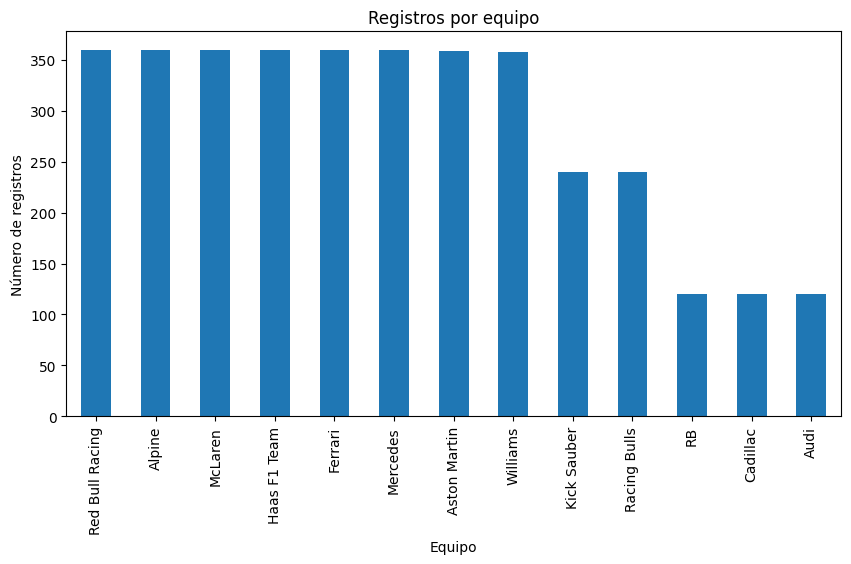

In [22]:
drivers["team_name"].value_counts()

drivers["team_name"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Registros por equipo")
plt.xlabel("Equipo")
plt.ylabel("Número de registros")
plt.show()

### Interpretación

La distribución de registros por equipo muestra una representación equilibrada de las escuderías participantes durante las temporadas analizadas.
Las pequeñas diferencias observadas se deben principalmente al número de sesiones registradas y a cambios producidos durante las temporadas, como sustituciones puntuales de pilotos o participaciones extraordinarias.

### Conclusiones

El dataset contiene información descriptiva de los pilotos participantes en las temporadas analizadas.

No se detectan registros duplicados significativos ni problemas de calidad relevantes.

# Dataset Stints

Los stints representan periodos continuos de utilización de un mismo compuesto de neumáticos.

Este dataset resulta especialmente útil para futuros análisis de estrategia de carrera.

In [23]:
stints.head()

,meeting_key,session_key,stint_number,driver_number,lap_start,lap_end,compound,tyre_age_at_start,season,country_name,location_name,session_name,session_type,date_start_session,date_end_session
0,1229,9468,1,55,1.0,4.0,MEDIUM,0,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
1,1229,9468,1,16,1.0,4.0,MEDIUM,0,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
2,1229,9468,1,31,1.0,4.0,MEDIUM,0,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
3,1229,9468,1,10,1.0,4.0,MEDIUM,0,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
4,1229,9468,1,23,1.0,4.0,SOFT,0,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00


In [24]:
stints.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9400 entries, 0 to 9399
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   meeting_key         9400 non-null   int64  
 1   session_key         9400 non-null   int64  
 2   stint_number        9400 non-null   int64  
 3   driver_number       9400 non-null   int64  
 4   lap_start           9378 non-null   float64
 5   lap_end             9378 non-null   float64
 6   compound            9385 non-null   object 
 7   tyre_age_at_start   9400 non-null   int64  
 8   season              9400 non-null   int64  
 9   country_name        9400 non-null   object 
 10  location_name       9400 non-null   object 
 11  session_name        9400 non-null   object 
 12  session_type        9400 non-null   object 
 13  date_start_session  9400 non-null   object 
 14  date_end_session    9400 non-null   object 
dtypes: float64(2), int64(6), object(7)
memory usage: 1.1+ M

In [28]:
stints.describe()

,meeting_key,session_key,stint_number,driver_number,lap_start,lap_end,tyre_age_at_start,season
count,9400.000000,9400.000000,9400.000000,9400.000000,9378.000000,9378.00000,9400.000000,9400.000000
mean,1256.727872,9927.100106,2.671170,29.502660,11.261570,19.73054,0.881915,2024.683191
std,16.426165,519.359565,1.612623,24.544632,12.991615,18.02079,2.855698,0.671058
min,1229.000000,9468.000000,1.000000,1.000000,1.000000,0.00000,0.000000,2024.000000
25%,1242.000000,9586.000000,1.000000,11.000000,1.000000,7.00000,0.000000,2024.000000
50%,1257.000000,9854.000000,2.000000,22.000000,7.000000,13.00000,0.000000,2025.000000
75%,1271.000000,9971.000000,4.000000,44.000000,15.000000,23.00000,0.000000,2025.000000
max,1286.000000,11299.000000,9.000000,87.000000,77.000000,78.00000,65.000000,2026.000000


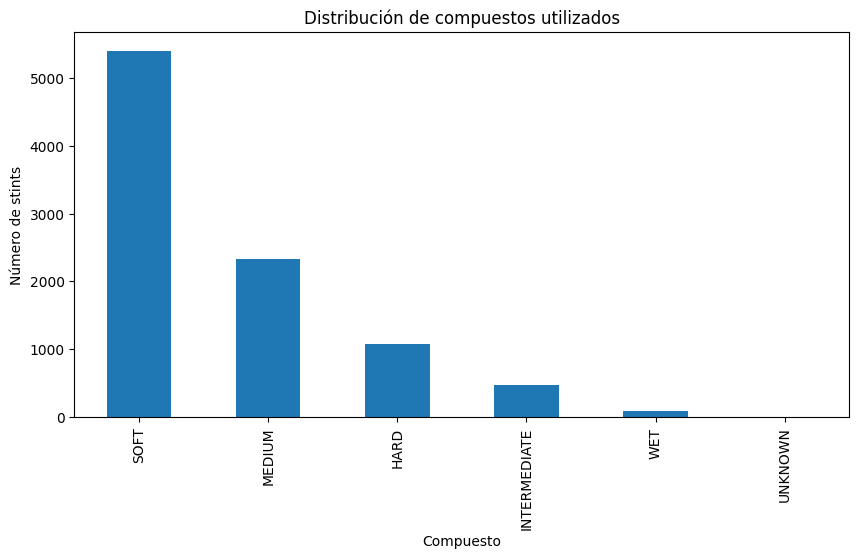

In [32]:
stints["compound"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Distribución de compuestos utilizados")
plt.xlabel("Compuesto")
plt.ylabel("Número de stints")
plt.show()

In [33]:
stints.groupby("session_name")["stint_number"].count()

session_name
Qualifying           5158
Race                 2980
Sprint                409
Sprint Qualifying     853
Name: stint_number, dtype: int64

In [39]:
#Duracion stint
stints["stint_laps"] = (
    stints["lap_end"]
    - stints["lap_start"]
    + 1
)

stints["stint_laps"].describe()

count    9378.000000
mean        9.468970
std        10.662593
min         0.000000
25%         3.000000
50%         4.000000
75%        12.000000
max        78.000000
Name: stint_laps, dtype: float64

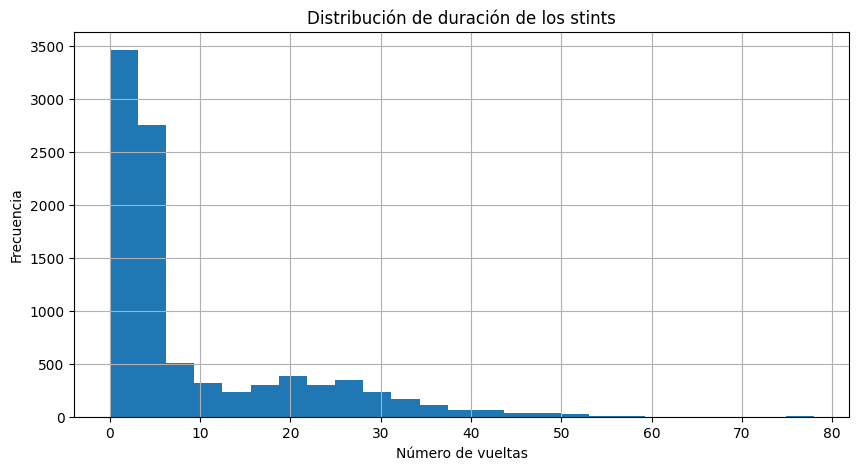

In [40]:
stints["stint_laps"].hist(
    bins=25,
    figsize=(10,5)
)

plt.title("Distribución de duración de los stints")
plt.xlabel("Número de vueltas")
plt.ylabel("Frecuencia")
plt.show()

### Interpretación

La duración de los stints presenta una elevada variabilidad, reflejando las diferentes estrategias utilizadas por los equipos en función del compuesto seleccionado, las condiciones de carrera y las características de cada circuito.

La mayoría de los stints se concentran en un rango reducido de vueltas, mientras que los valores extremos suelen corresponder a estrategias alternativas o situaciones especiales de carrera.

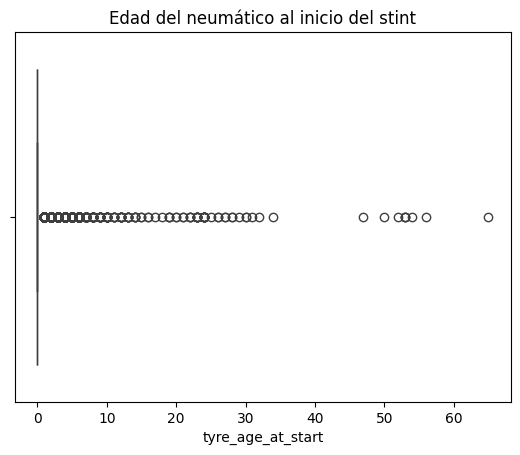

In [41]:
sns.boxplot(
    x=stints["tyre_age_at_start"]
)

plt.title("Edad del neumático al inicio del stint")
plt.show()

### Interpretación

La variable refleja el número de vueltas acumuladas por el neumático al comienzo de cada stint.

Valores elevados indican reutilización de neumáticos, una situación habitual durante sesiones de entrenamientos y clasificación.

## Conclusiones

El dataset de stints presenta una estructura consistente y una baja cantidad de valores nulos.
La información relativa a compuestos, duración de stint y edad de los neumáticos proporciona una base sólida para futuros análisis de estrategia y gestión de neumáticos durante las sesiones de Fórmula 1.

# Dataset Weather

Este dataset contiene información meteorológica registrada durante las distintas sesiones de Fórmula 1.

Las condiciones meteorológicas pueden influir directamente en el rendimiento de los monoplazas, la degradación de los neumáticos y las decisiones estratégicas de los equipos.

Por ello, resulta fundamental analizar la calidad de los datos y comprender la distribución de las principales variables climáticas antes de utilizarlas en análisis posteriores.

In [44]:
weather.head()

,date,session_key,air_temperature,track_temperature,humidity,pressure,wind_direction,meeting_key,wind_speed,rainfall,season,country_name,location_name,session_name,session_type,date_start_session,date_end_session
0,2024-03-01T15:46:51.334000+00:00,9468,18.2,22.2,48.0,1018.8,53,1229,2.7,0,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
1,2024-03-01T15:47:51.333000+00:00,9468,18.1,22.2,48.0,1018.8,51,1229,2.9,0,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
2,2024-03-01T15:48:51.320000+00:00,9468,18.1,22.2,48.0,1018.8,57,1229,2.1,0,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
3,2024-03-01T15:49:51.318000+00:00,9468,18.1,22.2,48.0,1018.8,48,1229,2.4,0,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
4,2024-03-01T15:50:51.334000+00:00,9468,18.1,22.2,48.0,1018.8,45,1229,2.3,0,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00


In [45]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15194 entries, 0 to 15193
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                15194 non-null  object 
 1   session_key         15194 non-null  int64  
 2   air_temperature     15194 non-null  float64
 3   track_temperature   15194 non-null  float64
 4   humidity            15194 non-null  float64
 5   pressure            15194 non-null  float64
 6   wind_direction      15194 non-null  int64  
 7   meeting_key         15194 non-null  int64  
 8   wind_speed          15194 non-null  float64
 9   rainfall            15194 non-null  int64  
 10  season              15194 non-null  int64  
 11  country_name        15194 non-null  object 
 12  location_name       15194 non-null  object 
 13  session_name        15194 non-null  object 
 14  session_type        15194 non-null  object 
 15  date_start_session  15194 non-null  object 
 16  date

In [46]:
weather.describe()

,session_key,air_temperature,track_temperature,humidity,pressure,wind_direction,meeting_key,wind_speed,rainfall,season
count,15194.000000,15194.000000,15194.000000,15194.000000,15194.000000,15194.000000,15194.000000,15194.000000,15194.000000,15194.000000
mean,9943.702317,23.288818,34.909734,54.280644,991.580032,180.908451,1257.083520,1.823443,0.050480,2024.696854
std,532.665672,4.988172,9.314115,17.037398,46.818704,102.127490,16.513375,1.059949,0.218941,0.680893
min,9468.000000,11.100000,12.000000,11.000000,780.300000,0.000000,1229.000000,0.000000,0.000000,2024.000000
25%,9594.000000,19.600000,28.200000,42.000000,989.200000,106.000000,1243.000000,1.000000,0.000000,2024.000000
50%,9858.000000,23.200000,35.000000,56.000000,1009.000000,186.000000,1257.000000,1.600000,0.000000,2025.000000
75%,9979.000000,27.300000,42.700000,66.000000,1016.400000,265.000000,1271.000000,2.400000,0.000000,2025.000000
max,11299.000000,34.300000,54.800000,95.000000,1031.000000,360.000000,1286.000000,7.300000,1.000000,2026.000000


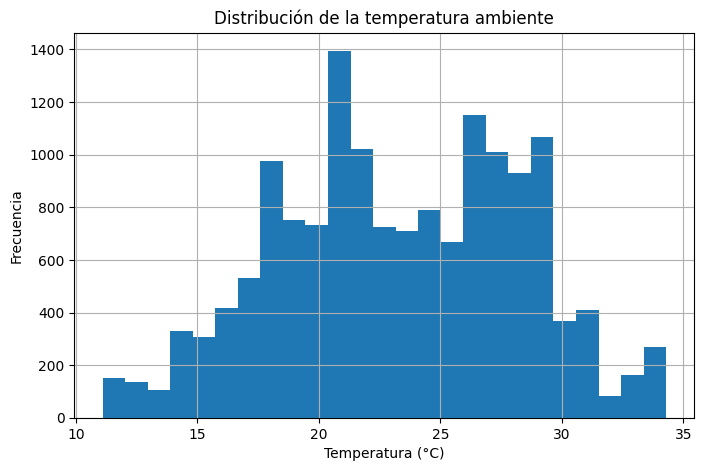

In [ ]:
##Distribucion Temperatura ambiente Histograma
weather["air_temperature"].hist(
    bins=25,
    figsize=(8,5)
)

plt.title("Distribución de la temperatura ambiente")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Frecuencia")
plt.show()

### Interpretación

La distribución de la temperatura ambiente muestra que la mayoría de las observaciones se concentran en un rango de temperaturas moderadas, propias de las condiciones habituales en las que se disputan los Grandes Premios de Fórmula 1.

No se aprecian valores extremadamente alejados del resto de observaciones, lo que sugiere una buena consistencia de los datos registrados.

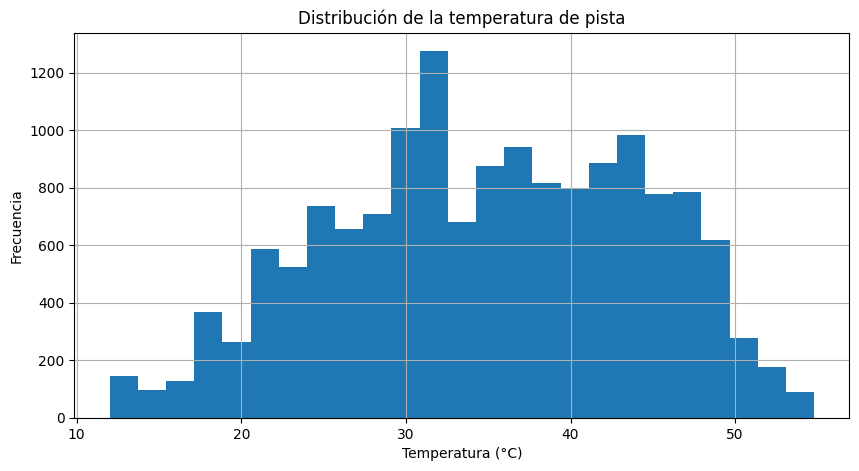

In [ ]:
##Temperatura en pista Histograma
weather["track_temperature"].hist(
    bins=25,
    figsize=(10, 5)
)

plt.title("Distribución de la temperatura de pista")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Frecuencia")
plt.show()

### Interpretación

La temperatura de pista presenta una mayor variabilidad que la temperatura ambiente, ya que además de las condiciones meteorológicas está influenciada por factores como la radiación solar, el tipo de asfalto y el horario de la sesión.
La distribución muestra que la mayor parte de las observaciones se concentra en rangos de temperatura compatibles con las condiciones habituales de competición, aunque se observan valores más extremos que en la temperatura ambiente.

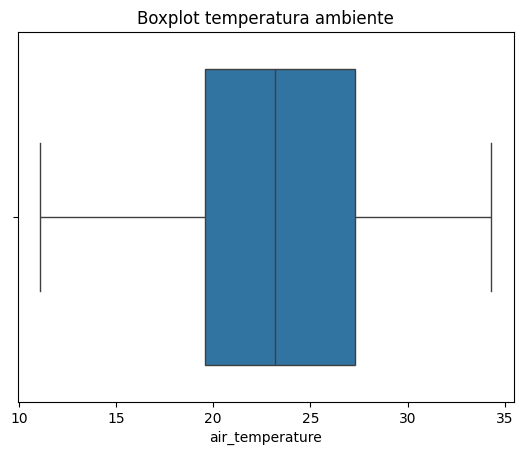

In [50]:
##Temperatura ambiente Boxplot
sns.boxplot(x=weather["air_temperature"])

plt.title("Boxplot temperatura ambiente")
plt.show()

### Interpretación

El boxplot permite visualizar la distribución general de la temperatura ambiente y detectar posibles valores atípicos.
La mayor parte de las observaciones se concentra dentro de un rango relativamente estable, mientras que los valores situados fuera de los límites del gráfico representan condiciones meteorológicas menos frecuentes registradas durante algunas sesiones específicas.

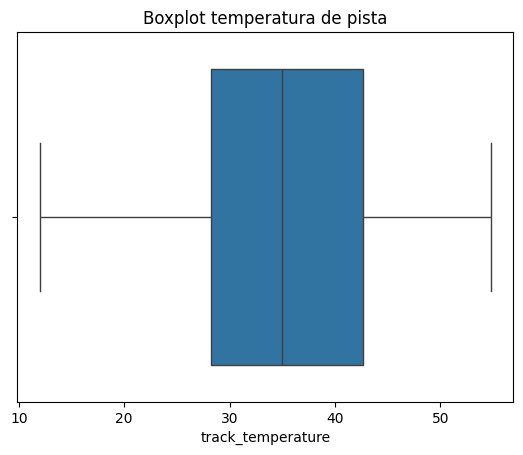

In [51]:
##Temperatura en pista Boxplot
sns.boxplot(x=weather["track_temperature"])

plt.title("Boxplot temperatura de pista")
plt.show()

### Interpretación

La temperatura de pista presenta una dispersión superior a la observada en la temperatura ambiente, lo que resulta coherente con la influencia adicional de factores como la exposición solar y las características del asfalto.
Los posibles valores extremos observados reflejan situaciones particulares de competición en circuitos especialmente cálidos o durante sesiones disputadas bajo condiciones meteorológicas excepcionales.

In [52]:
##Correlaciones
weather_num = weather[
    [
        "air_temperature",
            "track_temperature",
            "humidity",
            "pressure",
            "wind_speed",
            "wind_direction",
            "rainfall"
    ]
]

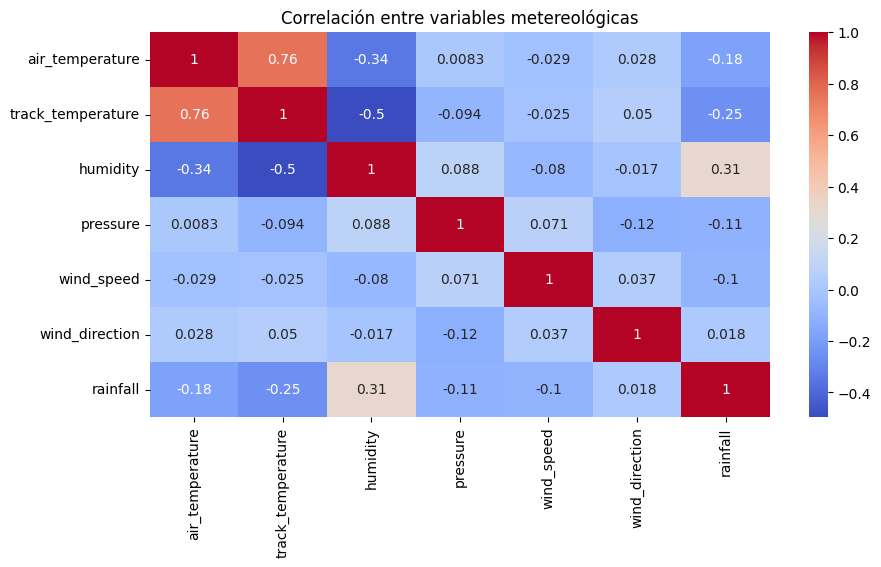

In [53]:
plt.figure(figsize=(10, 5))
sns.heatmap(weather_num.corr(), annot=True, cmap="coolwarm")

plt.title("Correlación entre variables metereológicas")
plt.show()

### Interpretación

La matriz de correlación muestra las relaciones existentes entre las distintas variables meteorológicas registradas durante las sesiones analizadas.
La correlación positiva más elevada se observa entre la temperatura ambiente y la temperatura de pista (0,76), indicando que ambas variables evolucionan de forma similar: cuando aumenta la temperatura ambiente, la pista tiende también a calentarse.
Las precipitaciones muestran una correlación positiva moderada con la humedad (0,31) y correlaciones negativas con las variables de temperatura, un comportamiento coherente con las condiciones meteorológicas habituales durante eventos de lluvia.

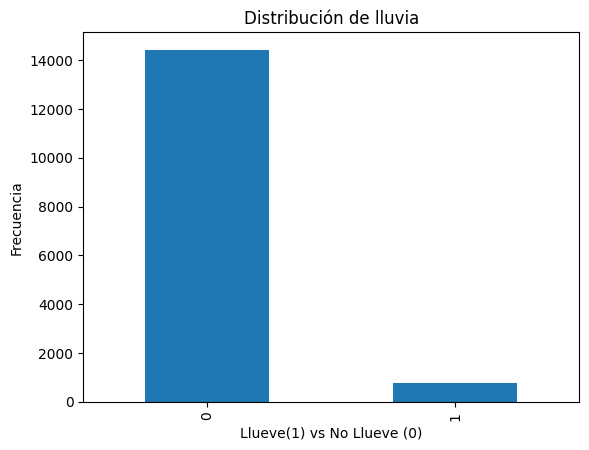

In [56]:
##Lluvia
weather["rainfall"].value_counts().plot(
    kind="bar"
)
plt.title("Distribución de lluvia")
plt.xlabel("Llueve(1) vs No Llueve (0)")
plt.ylabel("Frecuencia")
plt.show()

### Interpretación

La gran mayoría de las observaciones registradas corresponden a condiciones sin lluvia, mientras que únicamente una pequeña proporción de los registros presentan precipitaciones.
La variable rainfall podrá resultar especialmente útil para identificar condiciones meteorológicas y estudiar su impacto sobre el rendimiento de los pilotos y las estrategias de carrera.

## Conclusiones

El dataset meteorológico presenta una excelente calidad de datos, sin registros duplicados ni valores nulos.
Las variables registradas muestran relaciones coherentes entre sí, especialmente entre la temperatura ambiente y la temperatura de pista. Estas variables podrán resultar especialmente útiles para contextualizar el rendimiento de los pilotos y las condiciones de carrera.

# Dataset Race Control

Este dataset recoge los mensajes emitidos por Dirección de Carrera durante las distintas sesiones analizadas.

La información incluye eventos relevantes como banderas, incidentes, investigaciones, sanciones, despliegues de Safety Car y otras comunicaciones oficiales.

El análisis de este conjunto de datos permitirá comprender la frecuencia y distribución de los distintos eventos que pueden influir en el desarrollo de una sesión de Fórmula 1.

In [60]:
race_control.head()

,meeting_key,session_key,date,driver_number,lap_number,category,flag,scope,sector,qualifying_phase,message,season,country_name,location_name,session_name,session_type,date_start_session,date_end_session
0,1229,9468,2024-03-01T16:00:00+00:00,NaN,NaN,Flag,GREEN,Track,NaN,1.0,GREEN LIGHT - PIT EXIT OPEN,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
1,1229,9468,2024-03-01T16:00:00.260000+00:00,NaN,NaN,SessionStatus,NaN,NaN,NaN,1.0,SESSION STARTED,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
2,1229,9468,2024-03-01T16:04:42+00:00,NaN,NaN,Other,NaN,NaN,NaN,NaN,CAR 10 (GAS) TIME 1:32.434 DELETED - TRACK LIM...,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
3,1229,9468,2024-03-01T16:18:00+00:00,NaN,NaN,Flag,CHEQUERED,Track,NaN,1.0,CHEQUERED FLAG,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00
4,1229,9468,2024-03-01T16:18:00.233000+00:00,NaN,NaN,SessionStatus,NaN,NaN,NaN,1.0,SESSION FINISHED,2024,Bahrain,Sakhir,Qualifying,Qualifying,2024-03-01T16:00:00+00:00,2024-03-01T17:00:00+00:00


In [61]:
race_control.describe()

,meeting_key,session_key,driver_number,lap_number,sector,qualifying_phase,season
count,10078.000000,10078.000000,1692.000000,6241.000000,2380.000000,2019.000000,10078.000000
mean,1259.611530,10032.114606,29.943853,28.609357,10.465546,1.996038,2024.802540
std,16.832892,599.250143,23.893709,22.652318,5.518975,0.826940,0.715932
min,1229.000000,9468.000000,1.000000,0.000000,1.000000,1.000000,2024.000000
25%,1246.000000,9616.000000,12.000000,5.000000,6.000000,1.000000,2024.000000
50%,1261.000000,9888.000000,23.000000,27.000000,10.500000,2.000000,2025.000000
75%,1274.000000,9994.000000,41.000000,50.000000,15.000000,3.000000,2025.000000
max,1286.000000,11299.000000,87.000000,78.000000,27.000000,3.000000,2026.000000


In [59]:
race_control.isnull().sum().sort_values(
    ascending=False
)

driver_number         8386
qualifying_phase      8059
sector                7698
scope                 5214
flag                  5214
lap_number            3837
session_key              0
meeting_key              0
category                 0
date                     0
message                  0
season                   0
country_name             0
location_name            0
session_name             0
session_type             0
date_start_session       0
date_end_session         0
dtype: int64

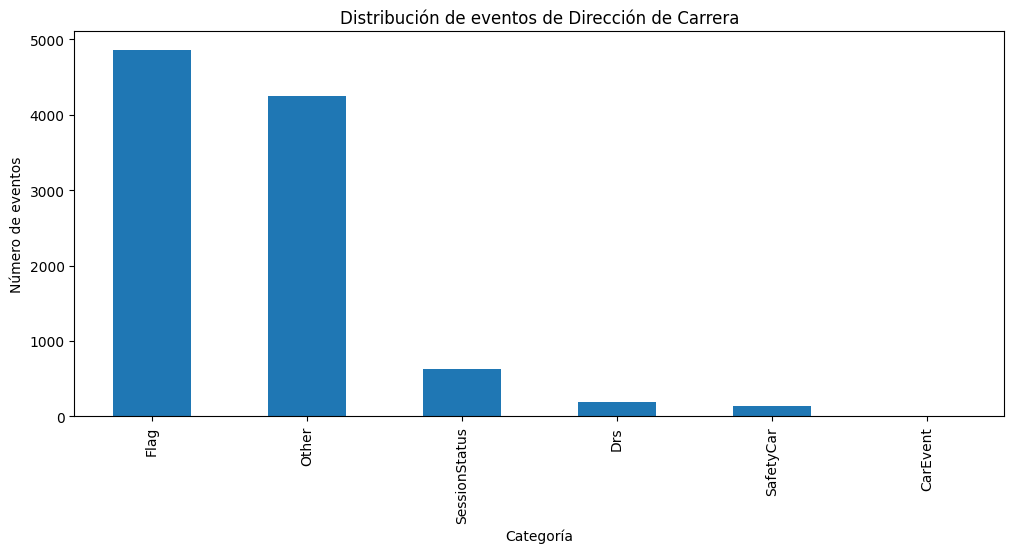

In [62]:
race_control["category"].value_counts().plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Distribución de eventos de Dirección de Carrera")
plt.xlabel("Categoría")
plt.ylabel("Número de eventos")
plt.show()

### Interpretación

La distribución de categorías permite identificar cuáles son los tipos de eventos más frecuentes registrados por Dirección de Carrera.

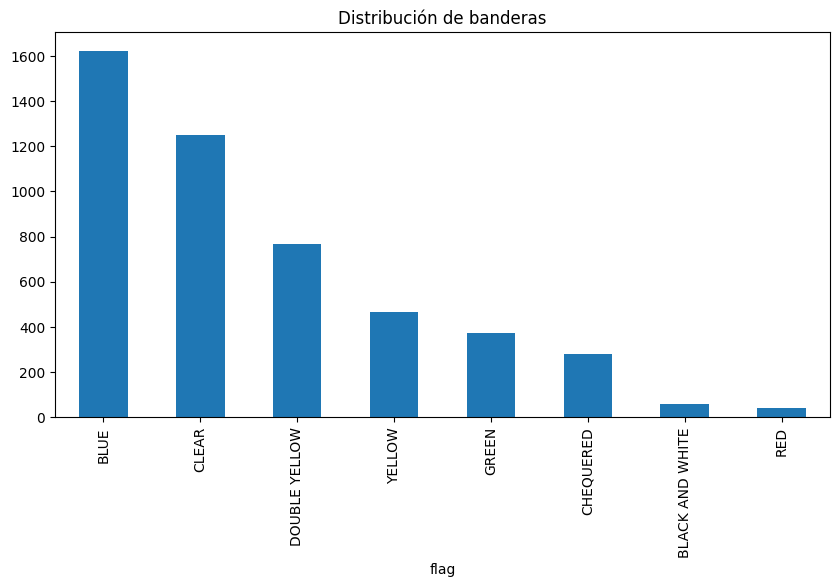

In [63]:
##Distribucion flag
race_control["flag"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Distribución de banderas")
plt.show()

### Interpretación

La distribución de banderas muestra los distintos tipos de señalización emitidos por Dirección de Carrera durante las temporadas analizadas.

Las banderas azules y las de pista libre (CLEAR) son los eventos más frecuentes registrados. Este comportamiento resulta coherente con el desarrollo habitual de las sesiones, especialmente durante entrenamientos y clasificación.
Las banderas amarillas y dobles amarillas (DOUBLE YELLOW) también presentan una presencia significativa, reflejando incidentes, salidas de pista o vehículos detenidos que requieren advertir a los pilotos sobre posibles peligros en el circuito.
Las banderas verdes aparecen con menor frecuencia y suelen utilizarse para indicar el final de una situación de peligro previamente señalizada.
Las banderas a cuadros corresponden al final de las sesiones, mientras que las banderas roja y blanca y negra son eventos poco frecuentes asociados a interrupciones excepcionales o advertencias disciplinarias.

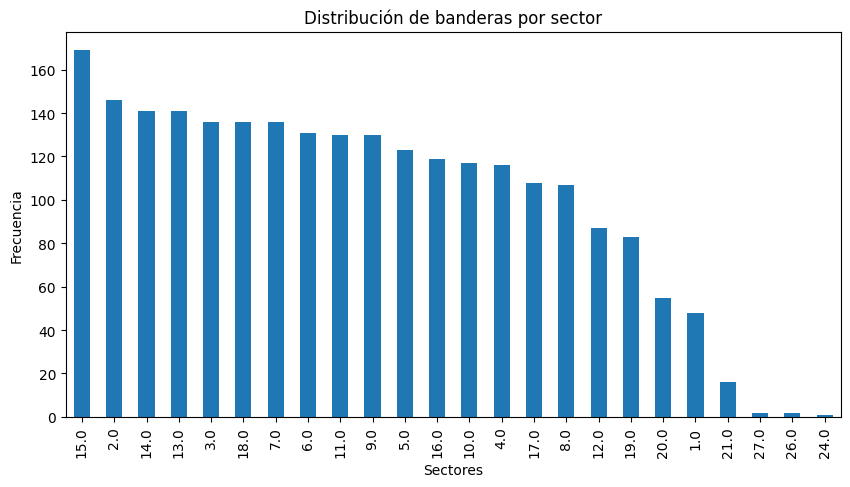

In [66]:
##Banderas por sector
race_control["sector"].value_counts().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Distribución de banderas por sector")
plt.xlabel("Sectores")
plt.ylabel("Frecuencia")
plt.show()

<Axes: xlabel='sector'>

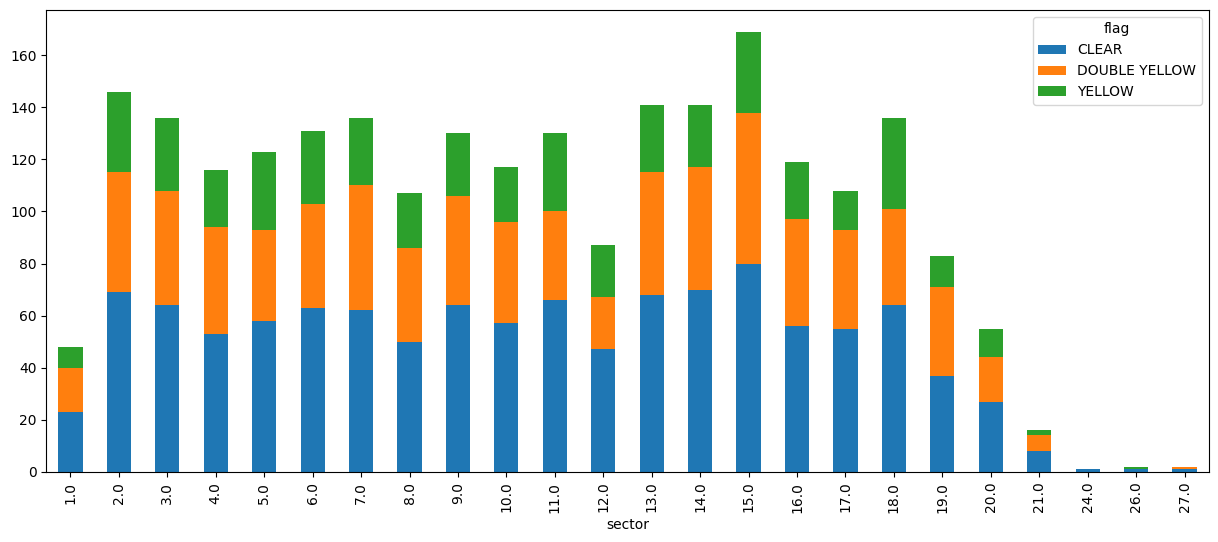

In [68]:
##Cruzamos secotres con tipo de bandera 
sector_flag = pd.crosstab(
    race_control["sector"],
    race_control["flag"]
)

sector_flag.plot(
    kind="bar",
    stacked=True,
    figsize=(15,6)
)

### Interpretación

El análisis por sectores permite identificar las zonas del circuito donde se concentran un mayor número de eventos registrados por Dirección de Carrera.

Sin embargo, la distribución está influenciada ya que existen distintos tipos de bandera. Para ello, cruzar los datos resulta especialmente útil analizar conjuntamente el sector y el tipo de bandera para diferenciar entre situaciones de tráfico, incidentes o neutralizaciones de carrera.

## Conclusiones

Los análisis realizados permiten identificar los tipos de bandera más frecuentes y las zonas donde se concentran un mayor número de incidencias o comunicaciones. A pesar de presentar numerosos valores nulos en determinadas columnas, estos son coherentes con los tipos de eventos registrados.

# Conclusiones generales

Tras el análisis exploratorio de los datasets de metadatos obtenidos mediante la API OpenF1, se observa que la calidad general de los datos es elevada y adecuada para continuar con las siguientes fases del proyecto.

**Sessions** presenta una estructura consistente y sin valores nulos, permitiendo identificar correctamente las distintas sesiones disputadas durante las temporadas analizadas.
**Drivers** proporciona información detallada sobre pilotos y equipos, siendo los valores nulos detectados consecuencia de campos descriptivos opcionales y no de problemas de calidad en los datos.
**Stints**, se ha comprobado la correcta representación de los compuestos de neumáticos utilizados y de las estrategias desarrolladas por los equipos a lo largo de las diferentes sesiones. Este conjunto de datos resulta especialmente relevante para futuros análisis relacionados con la gestión de neumáticos y las estrategias de carrera.
**Weather** destaca por su excelente calidad, sin registros duplicados ni valores nulos. El análisis de correlaciones ha permitido identificar relaciones coherentes entre las distintas variables meteorológicas, 
**Race Control** recoge una amplia variedad de eventos oficiales de Dirección de Carrera. Aunque presenta una cantidad considerable de valores nulos en determinadas columnas, estos se corresponden con la propia naturaleza de los distintos tipos de mensajes, pero no representan errores en los datos. El análisis de banderas y sectores ha permitido identificar los eventos más frecuentes y las zonas donde se concentran un mayor número de incidencias o comunicaciones oficiales.

En conjunto, los datasets analizados ofrecen una base sólida para continuar con la fase de limpieza y transformación de datos. La información obtenida permitirá enriquecer los análisis posteriores relacionados con el rendimiento de pilotos, estrategias de carrera, comportamiento de los neumáticos y condiciones meteorológicas, constituyendo el punto de partida para el desarrollo del sistema de inteligencia de carrera y del dashboard final del proyecto.